Business Objective: A business firm has been performing well financially with annual sales of over 2.6 billons from  2019-2025, however sales started to decline in 2026 to 1 billion. The goal of this project is to build a scalable model that accurately predicts customers that have tendency to churn and revenue that will be lost if such customer churn. The project also extends to descriptive analysis that aim to uncover trends and factors that contribute to a customer churning.

In [5]:
!pip install --quiet google-cloud-bigquery pandas numpy scikit-learn factor_analyzer xgboost shap statsmodels matplotlib seaborn joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [6]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns

imported customer_Data table from big query

In [7]:


from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

client = bigquery.Client(
    project="datascience-507912",

)

query = """
SELECT
    *
FROM `datascience-507912.Customer_Churn.customer_Data`
"""

df = client.query(query).to_dataframe()

Explorative data analysis  and data cleaning

In [ ]:
print("Records loaded:", len(df))
print("Numbers of fields:", len(df.columns))
df.head()

Records loaded: 314844
Numbers of fields: 48


,customer_id,full_name,age,age_group,gender,state,signup_date,tenure_months,tenure_group,membership_tier,...,days_since_last_login,days_since_last_login_group,email_open_rate,tickets_last_year,ticket_group,complaint_category,avg_resolution_hours,avg_resolution_group,escalated,issue_status
0,1444270,Customer 444269,27,26-35,Male,Karnataka,2018-08-04,100,Over 3 years,Silver,...,0,Over 1year,0.33,8,High,Other,11.8,1 day,True,Closed
1,1029696,Customer 29695,43,35-50,Other,Telangana,2018-09-23,104,Over 3 years,Silver,...,0,Over 1year,0.09,5,Moderate,Delivery Delay,5.4,1 day,False,Closed
2,1029696,Customer 29695,43,35-50,Other,Telangana,2018-09-23,104,Over 3 years,Silver,...,0,Over 1year,0.09,5,Moderate,Delivery Delay,5.4,1 day,False,Closed
3,1029696,Customer 29695,43,35-50,Other,Telangana,2018-09-23,104,Over 3 years,Silver,...,0,Over 1year,0.09,5,Moderate,Delivery Delay,5.4,1 day,False,Closed
4,1050871,Customer 50870,24,18-25,Male,Gujarat,2022-12-16,89,Over 3 years,Basic,...,0,Over 1year,0.59,7,High,Payment Issue,41.5,2 days,True,Open


In [8]:
df['customer_id'].duplicated().sum()

np.int64(201360)

In [9]:
df = df.drop_duplicates(subset='customer_id', keep='first')
df.head(5)

,customer_id,full_name,age,age_group,gender,state,signup_date,tenure_months,tenure_group,membership_tier,...,days_since_last_login,days_since_last_login_group,email_open_rate,tickets_last_year,ticket_group,complaint_category,avg_resolution_hours,avg_resolution_group,escalated,issue_status
0,1444270,Customer 444269,27,26-35,Male,Karnataka,2018-08-04,100,Over 3 years,Silver,...,0,Over 1year,0.33,8,High,Other,11.8,1 day,True,Closed
1,1029696,Customer 29695,43,35-50,Other,Telangana,2018-09-23,104,Over 3 years,Silver,...,0,Over 1year,0.09,5,Moderate,Delivery Delay,5.4,1 day,False,Closed
4,1050871,Customer 50870,24,18-25,Male,Gujarat,2022-12-16,89,Over 3 years,Basic,...,0,Over 1year,0.59,7,High,Payment Issue,41.5,2 days,True,Open
7,1340336,Customer 340335,59,50+,Female,West Bengal,2025-02-05,107,Over 3 years,Silver,...,0,Over 1year,0.51,5,Moderate,Account Issue,58.4,2 days,True,Escalated
11,1137281,Customer 137280,54,50+,Male,Telangana,2021-02-11,33,3 years,Gold,...,0,Over 1year,0.44,6,High,Wrong Item,33.7,2 days,True,Escalated


In [ ]:
df.isna().sum()

,0
customer_id,0
full_name,0
age,0
age_group,0
gender,0
state,0
signup_date,0
tenure_months,0
tenure_group,0
membership_tier,0


Checking normal distribution, skewness and kurtosis of numerical variables in customer_data

In [ ]:
from scipy.stats import skew, kurtosis

numeric_columns =['total_orders','total_spent','total_returns','lifetime_value',
 'payment_failures','average_monthly_spend','cart_abandon_rate',
 'email_open_rate','tickets_last_year','avg_resolution_hours','age', 'wishlist_items', 'tenure_months','sales']

numeric_cols = [col for col in numeric_columns if col in df.columns]
skew_values = df[numeric_cols].skew()
kurtosis_values = df[numeric_cols].kurtosis()
skew_df = skew_values
kurtosis_df = kurtosis_values
distribution_df = pd.DataFrame({'Skew': skew_df, 'Kurtosis': kurtosis_df}, index=numeric_cols)
distribution_df = distribution_df.sort_values(by='Skew', ascending=False)
print(distribution_df)

                           Skew  Kurtosis
lifetime_value          1.22709  1.187755
sales                  0.981018  0.327429
total_spent            0.949292  0.115424
total_returns          0.074652 -1.226399
avg_resolution_hours   0.005597 -1.197021
age                    0.004973 -1.199962
email_open_rate        0.004633 -1.194967
wishlist_items          0.00336 -1.200215
total_orders           0.002767 -1.197516
tickets_last_year      0.002341 -1.239707
cart_abandon_rate      0.000672  -1.20152
tenure_months         -0.000898 -1.199849
average_monthly_spend -0.001014  -1.20214
payment_failures      -0.006706 -1.267875


Visualising distribution

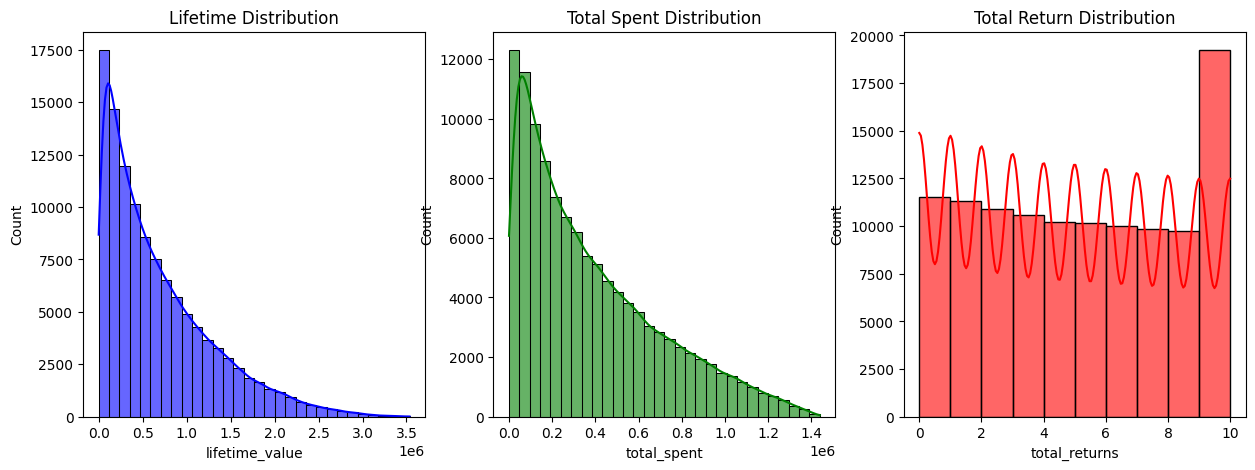

In [ ]:
plt.figure(figsize=(15, 5))

# Plot lifetime_value distribution
plt.subplot(1, 3, 1)
sns.histplot(df['lifetime_value'], bins=30, alpha=0.6, color='b', kde=True)
plt.title("Lifetime Distribution")

# Plot total_spent distribution
plt.subplot(1, 3, 2)
sns.histplot(df['total_spent'], bins=30,  alpha=0.6, color='g', kde=True)
plt.title("Total Spent Distribution")

# Plot total_return distribution
plt.subplot(1, 3, 3)
sns.histplot(df['total_returns'], bins=10,alpha=0.6, color='r', kde=True)
plt.title("Total Return Distribution")

plt.show()

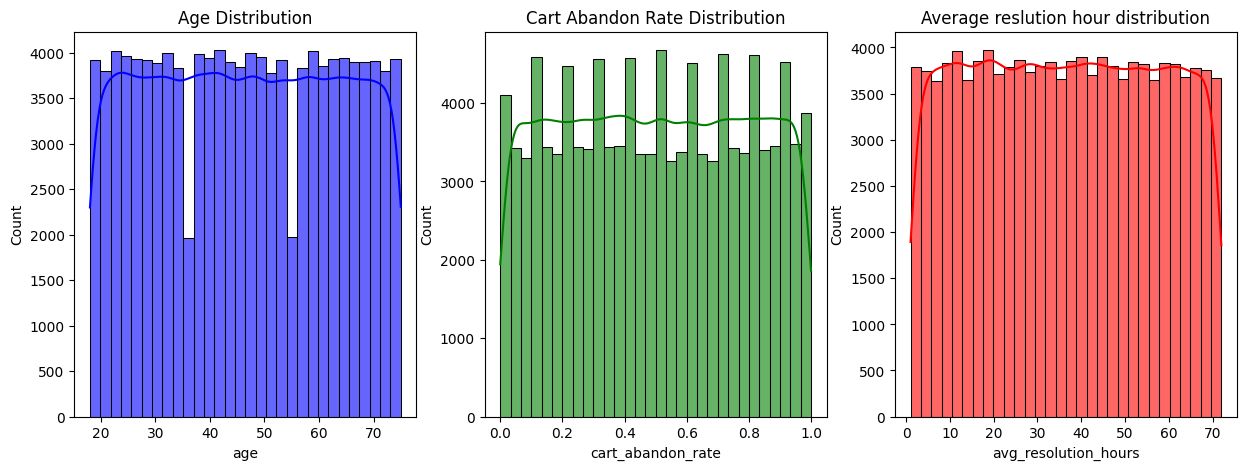

In [ ]:
plt.figure(figsize=(15, 5))

# Plot lifetime_value distribution
plt.subplot(1, 3, 1)
sns.histplot(df['age'], bins=30, alpha=0.6, color='b', kde=True)
plt.title("Age Distribution")

# Plot total_spent distribution
plt.subplot(1, 3, 2)
sns.histplot(df['cart_abandon_rate'], bins=30,  alpha=0.6, color='g', kde=True)
plt.title("Cart Abandon Rate Distribution")

# Plot total_return distribution
plt.subplot(1, 3, 3)
sns.histplot(df['avg_resolution_hours'], bins=30,alpha=0.6, color='r', kde=True)
plt.title("Average reslution hour distribution")

# Plot payment failure

plt.show()

Outlier Detection

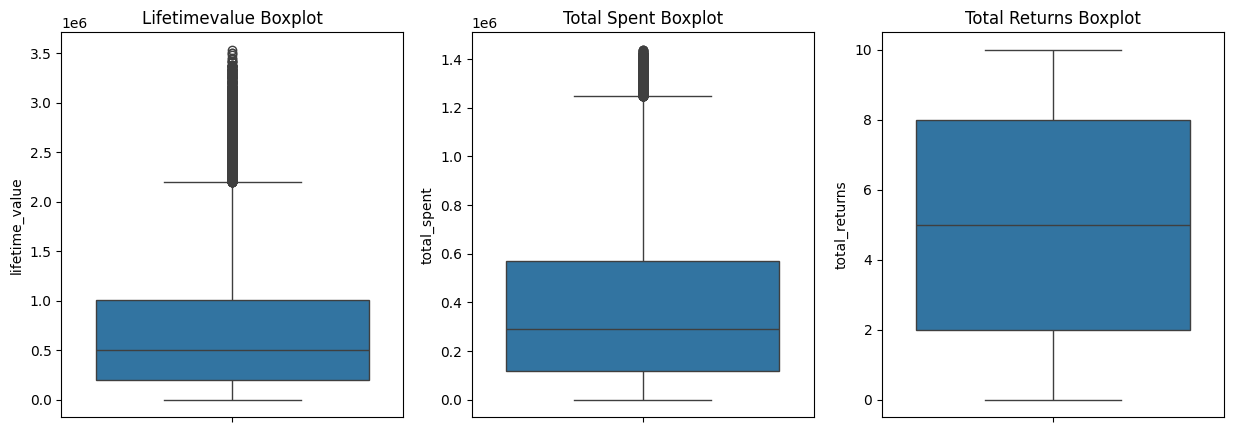

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
sns.boxplot(df, y='lifetime_value')
plt.title('Lifetimevalue Boxplot')

plt.subplot(1,3,2)
sns.boxplot(df, y='total_spent')
plt.title('Total Spent Boxplot')

plt.subplot(1,3,3)
sns.boxplot(df, y='total_returns')
plt.title('Total Returns Boxplot')

plt.show()


Querying outliers

In [ ]:
# checking outliers above the range on life_time value column
df_lifetime_value = df['lifetime_value']
df_lifetime_value[df_lifetime_value > 2000000]

,lifetime_value
816,2134288.20
826,2100446.27
829,2137644.70
835,2239927.72
846,2059171.07
...,...
314822,2220303.79
314824,2929484.11
314835,3031800.23
314837,2036638.30


In [ ]:
# checking outliers below median value on life time value column
df_lifetime_value = df['lifetime_value']
df_lifetime_value[df_lifetime_value < 500000]

,lifetime_value
0,2250.41
1,3439.84
4,6828.28
7,5152.49
11,10550.27
...,...
314379,342405.51
314383,403708.92
314386,400584.31
314400,465613.28


In [ ]:
#checking outliers above range in total spent column
df_total_spent = df['total_spent']
df_total_spent[df_total_spent > 1200000]


,total_spent
884,1210826.40
885,1225491.60
887,1236312.98
894,1237385.05
896,1299532.88
...,...
314829,1212297.54
314835,1233826.51
314837,1269626.88
314841,1328888.25


In [ ]:
#checking outliers below median value in total spent column
df_total_spent = df['total_spent']
df_total_spent[df_total_spent > 300000]


,total_spent
436,301620.80
437,303528.75
439,303922.80
440,305464.08
442,307928.72
...,...
314829,1212297.54
314835,1233826.51
314837,1269626.88
314841,1328888.25


Outliers are not removed in lifetime value and total spent because they may be true depending on purchasing power of consumers. Further investigation will be made in real life scenarios

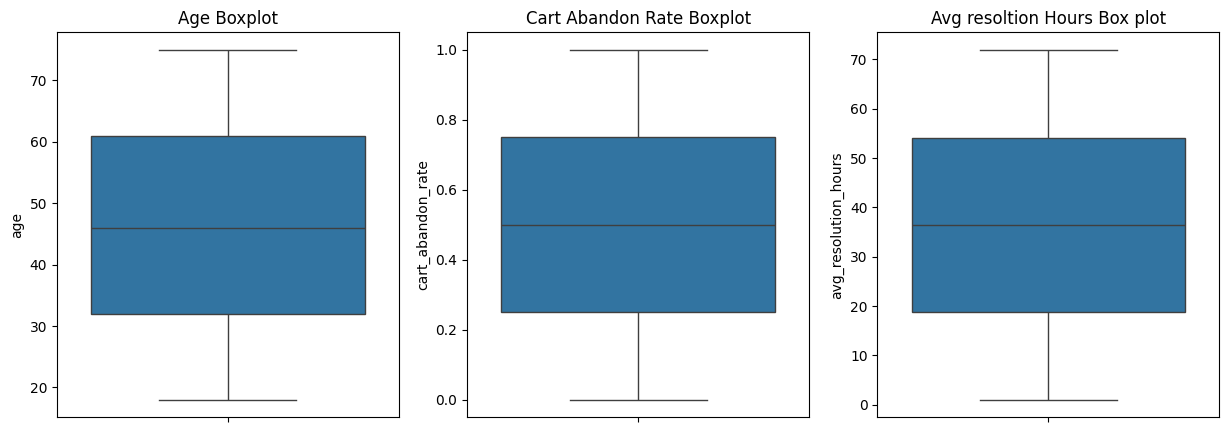

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
sns.boxplot(df, y='age')
plt.title('Age Boxplot')

plt.subplot(1,3,2)
sns.boxplot(df, y='cart_abandon_rate')
plt.title('Cart Abandon Rate Boxplot')

plt.subplot(1,3,3)
sns.boxplot(df, y='avg_resolution_hours')
plt.title('Avg resoltion Hours Box plot')

plt.show()


Interactive Data Visualisation

Yearly Sales

In [ ]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# Convert 'order_date' to datetime objects
df['order_date'] = pd.to_datetime(df['order_date'])

# Aggregate sales by month
df['order_year'] = df['order_date'].dt.to_period('Y')
yearly_sales = df.groupby('order_year')['sales'].sum().reset_index()
yearly_sales['order_year'] = yearly_sales['order_year'].astype(str)

# Create a Plotly figure for monthly sales
fig5 = go.Figure()
fig5.add_trace(go.Scatter(x=yearly_sales['order_year'], y=yearly_sales['sales'], mode='lines+markers', name='Monthly Sales'))
fig5.update_layout(title='Yearly Sales Over Time', xaxis_title='Year', yaxis_title='Total Sales', template='plotly_dark')
fig5.show()

Yearly Churn

In [ ]:


# Aggregate churn by year
df['order_year'] = df['order_date'].dt.to_period('Y')
yearly_churn = df[df['churn'] == True].groupby('order_year')['churn'].sum().reset_index(name='total_churn')
yearly_churn['order_year'] = yearly_churn['order_year'].astype(str)

# Create a Plotly figure for yearly churn
fig = go.Figure()
fig.add_trace(go.Scatter(x=yearly_churn['order_year'], y=yearly_churn['total_churn'], mode='lines+markers', name='Yearly Churn'))
fig.update_layout(title='Yearly Churn Over Time', xaxis_title='Year', yaxis_title='Number of Churned Customers', template='plotly_dark')
fig.show()

Sales by membership_tier and year

In [ ]:
import plotly.express as px
#sun burn chart
# membership sales by year
yearly_membership_sales = df.groupby(['order_year', 'membership_tier'])['sales'].sum().reset_index()

# Create a sunburst chart

fig=px.treemap(yearly_membership_sales, path=['order_year', 'membership_tier'], values='sales',
           color='sales', color_continuous_scale='RdBu', color_continuous_midpoint=
           yearly_membership_sales['sales'].mean())
fig.update_layout(margin=dict(t=30, l=25, r=25, b=25))
fig.show()

Sales by age group

In [ ]:
# age group sales visualisation
yearly_sales_age_group = df.groupby(['order_year', 'age_group'])['sales'].sum().reset_index()
fig = px.sunburst(yearly_sales_age_group, path=['order_year','age_group'], values='sales')
fig.update_layout(margin=dict(t=30, l=0, r=0, b=0))
fig.show()

sales per state

In [ ]:
yearly_sales_per_state = df.groupby(['order_year', 'state'])['sales'].sum().reset_index()
yearly_sales_per_state['order_year'] = yearly_sales_per_state['order_year'].astype(str)
fig = px.bar(yearly_sales_per_state, x='order_year', y='sales', color='state', barmode='group',
             labels={'sales': 'Total Sales', 'order_year': 'Year', 'state': 'State'},)
fig.update_layout(title='Yearly Sales per State', xaxis_title='Year', yaxis_title='State', template='plotly_dark')
fig.show()


Downloaded the cleaned data for further analysis


In [10]:
from google.colab import files
output_file_path = 'customer_churn_cleaned_data.csv'
df.to_csv('customer_churn_cleaned_data.csv', index=False)
files.download('customer_churn_cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The next steps is statiscal analysis check stastical analysis in the project folder